In [3]:
import duckdb
import numpy as np
import pandas as pd
import torch
from torch import nn

In [7]:
# Load from DuckDB in /data
if "con" in globals():
    try:
        con.close()
    except Exception:
        pass

con = duckdb.connect("data/ncaam.db", read_only=True)
df = con.execute("SELECT * FROM team_season_stats").fetchdf()
con.close()

# Target: round reached; include non-tournament teams as a class
df = df.copy()
df["TournamentFinishRound"] = df["TournamentFinishRound"].fillna("Did Not Make Tournament")

# Train/test split by season
test_season = "2024-25"
train_df = df[df["Season"] != test_season].copy()
test_df = df[df["Season"] == test_season].copy()

if test_df.empty:
    raise ValueError(f"No rows found for test season {test_season}.")

# Build numeric feature matrix
exclude_cols = {
    "Team",
    "TeamKey",
    "Season",
    "SquadID",
    "TournamentFinishRound",
}
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

for c in X_train.columns:
    if X_train[c].dtype == bool:
        X_train[c] = X_train[c].astype(int)
        X_test[c] = X_test[c].astype(int)

# Coerce everything to numeric and fill missing
X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# Standardize using train stats only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0).replace(0, 1)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Force numeric tensor-friendly dtype
X_train = X_train.to_numpy(dtype=np.float32)
X_test = X_test.to_numpy(dtype=np.float32)

# Encode labels
y_train_raw = train_df["TournamentFinishRound"].astype(str)
y_test_raw = test_df["TournamentFinishRound"].astype(str)

classes = sorted(y_train_raw.unique().tolist())
if any(c not in classes for c in y_test_raw.unique()):
    unseen = sorted(set(y_test_raw.unique()) - set(classes))
    raise ValueError(f"Test set has unseen classes: {unseen}")

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_train = y_train_raw.map(class_to_idx).to_numpy(dtype=np.int64)
y_test = y_test_raw.map(class_to_idx).to_numpy(dtype=np.int64)

# Torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Simple feed-forward neural network
input_dim = X_train_t.shape[1]
num_classes = len(classes)

model = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes),
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train
epochs = 120
for epoch in range(epochs):
    model.train()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        with torch.no_grad():
            preds = model(X_train_t).argmax(dim=1)
            train_acc = (preds == y_train_t).float().mean().item()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Train Acc: {train_acc:.3f}")

# Evaluate on 2024-25
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_preds = test_logits.argmax(dim=1)
    test_acc = (test_preds == y_test_t).float().mean().item()

print(f"\nTest season: {test_season}")
print(f"Rows in train: {len(train_df):,}")
print(f"Rows in test: {len(test_df):,}")
print(f"Num features: {input_dim}")
print(f"Classes: {classes}")
print(f"Test accuracy: {test_acc:.3f}")

# Quick per-class support summary on test
test_summary = (
    pd.DataFrame({
        "true": y_test_raw.values,
        "pred": [idx_to_class[i.item()] for i in test_preds],
    })
    .groupby("true", as_index=False)
    .size()
    .rename(columns={"size": "test_count"})
)
print("\nTest class counts:")
print(test_summary.to_string(index=False))

Epoch  20 | Loss: 0.8825 | Train Acc: 0.811
Epoch  40 | Loss: 0.4875 | Train Acc: 0.858
Epoch  60 | Loss: 0.3414 | Train Acc: 0.886
Epoch  80 | Loss: 0.2799 | Train Acc: 0.896
Epoch 100 | Loss: 0.2502 | Train Acc: 0.907
Epoch 120 | Loss: 0.2329 | Train Acc: 0.906

Test season: 2024-25
Rows in train: 3,187
Rows in test: 364
Num features: 40
Classes: ['Did Not Make Tournament', 'Elite 8', 'Final Four', 'First Four', 'National Championship', 'Round of 32', 'Round of 64', 'Sweet 16']
Test accuracy: 0.920

Test class counts:
                   true  test_count
Did Not Make Tournament         298
                Elite 8           4
             Final Four           2
             First Four           3
  National Championship           2
            Round of 32          16
            Round of 64          31
               Sweet 16           8


Per-class precision/recall/f1:
                         precision    recall  f1-score    support
Did Not Make Tournament   1.000000  1.000000  1.000000  298.00000
Elite 8                   0.000000  0.000000  0.000000    4.00000
Final Four                0.000000  0.000000  0.000000    2.00000
First Four                0.000000  0.000000  0.000000    3.00000
National Championship     0.000000  0.000000  0.000000    2.00000
Round of 32               0.450000  0.562500  0.500000   16.00000
Round of 64               0.764706  0.838710  0.800000   31.00000
Sweet 16                  0.166667  0.250000  0.200000    8.00000
accuracy                  0.920330  0.920330  0.920330    0.92033
macro avg                 0.297672  0.331401  0.312500  364.00000
weighted avg              0.907251  0.920330  0.913187  364.00000


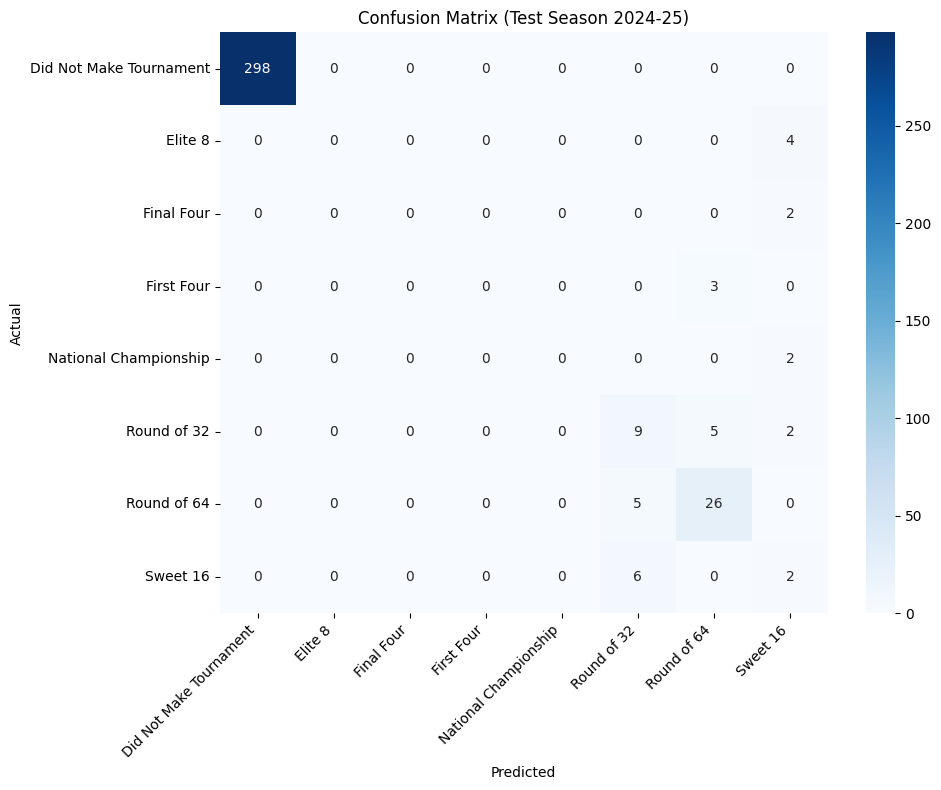

In [8]:
# Confusion matrix and per-class precision/recall on 2024-25 test set
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Build label vectors from objects created in the training cell
y_true_labels = y_test_raw.values
y_pred_labels = [idx_to_class[i.item()] for i in test_preds]

# Per-class metrics table
report = classification_report(
    y_true_labels,
    y_pred_labels,
    labels=classes,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
print("Per-class precision/recall/f1:")
print(report_df.loc[classes + ["accuracy", "macro avg", "weighted avg"]].to_string())

# Confusion matrix heatmap
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.title("Confusion Matrix (Test Season 2024-25)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2026-03-31 23:23:25,929 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-31 23:23:25,972 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


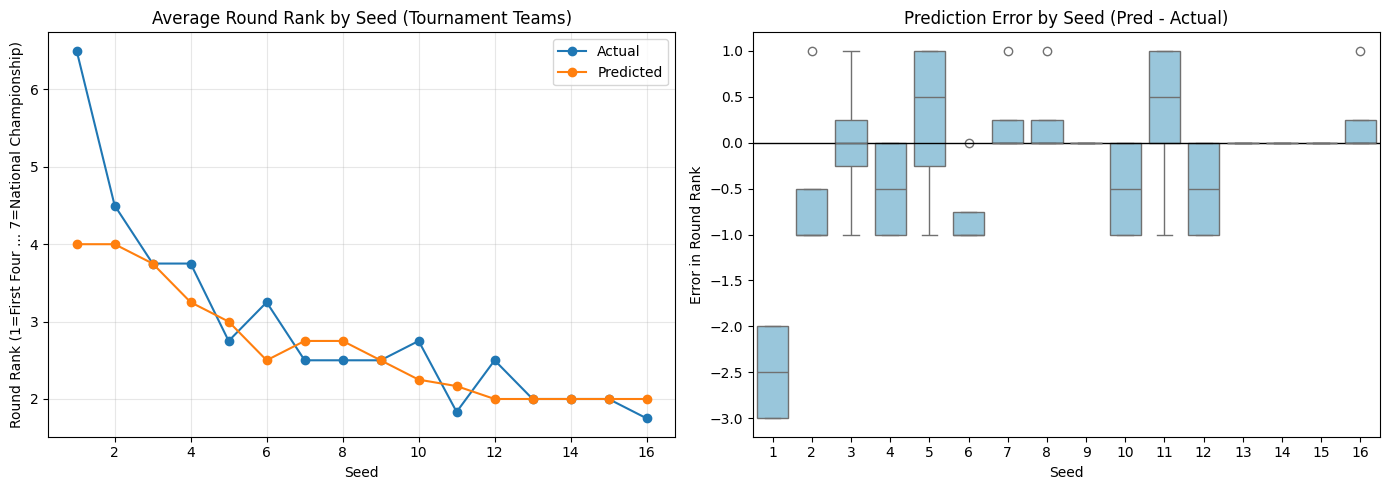

Tournament teams: actual vs predicted by seed
 TournamentSeed  Teams  ActualMean  PredMean      MAE
              1      4    6.500000  4.000000 2.500000
              2      4    4.500000  4.000000 1.000000
              3      4    3.750000  3.750000 0.500000
              4      4    3.750000  3.250000 0.500000
              5      4    2.750000  3.000000 0.750000
              6      4    3.250000  2.500000 0.750000
              7      4    2.500000  2.750000 0.250000
              8      4    2.500000  2.750000 0.250000
              9      4    2.500000  2.500000 0.000000
             10      4    2.750000  2.250000 0.500000
             11      6    1.833333  2.166667 0.666667
             12      4    2.500000  2.000000 0.500000
             13      4    2.000000  2.000000 0.000000
             14      4    2.000000  2.000000 0.000000
             15      4    2.000000  2.000000 0.000000
             16      4    1.750000  2.000000 0.250000


In [9]:
# Tournament teams only: predicted vs actual round reached by seed
import matplotlib.pyplot as plt
import seaborn as sns

round_to_rank = {
    "First Four": 1,
    "Round of 64": 2,
    "Round of 32": 3,
    "Sweet 16": 4,
    "Elite 8": 5,
    "Final Four": 6,
    "National Championship": 7,
}

plot_df = test_df.copy()
plot_df["ActualRound"] = y_test_raw.values
plot_df["PredRound"] = [idx_to_class[i.item()] for i in test_preds]
plot_df = plot_df[plot_df["ActualRound"] != "Did Not Make Tournament"].copy()
plot_df = plot_df[pd.to_numeric(plot_df["TournamentSeed"], errors="coerce").notna()].copy()
plot_df["TournamentSeed"] = plot_df["TournamentSeed"].astype(int)
plot_df["ActualRank"] = plot_df["ActualRound"].map(round_to_rank)
plot_df["PredRank"] = plot_df["PredRound"].map(round_to_rank)

if plot_df.empty:
    print("No tournament-team rows available for plotting in test season.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: average reached round by seed
    seed_summary = (
        plot_df.groupby("TournamentSeed", as_index=False)
        .agg(ActualMean=("ActualRank", "mean"), PredMean=("PredRank", "mean"))
        .sort_values("TournamentSeed")
    )

    axes[0].plot(seed_summary["TournamentSeed"], seed_summary["ActualMean"], marker="o", label="Actual")
    axes[0].plot(seed_summary["TournamentSeed"], seed_summary["PredMean"], marker="o", label="Predicted")
    axes[0].set_title("Average Round Rank by Seed (Tournament Teams)")
    axes[0].set_xlabel("Seed")
    axes[0].set_ylabel("Round Rank (1=First Four ... 7=National Championship)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: prediction error by seed
    plot_df["Error"] = plot_df["PredRank"] - plot_df["ActualRank"]
    sns.boxplot(data=plot_df, x="TournamentSeed", y="Error", ax=axes[1], color="#8ecae6")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Prediction Error by Seed (Pred - Actual)")
    axes[1].set_xlabel("Seed")
    axes[1].set_ylabel("Error in Round Rank")

    plt.tight_layout()
    plt.show()

    # Optional table for direct comparison
    compare_tbl = (
        plot_df.groupby("TournamentSeed", as_index=False)
        .agg(
            Teams=("Team", "count"),
            ActualMean=("ActualRank", "mean"),
            PredMean=("PredRank", "mean"),
            MAE=("Error", lambda s: np.mean(np.abs(s))),
        )
        .sort_values("TournamentSeed")
    )
    print("Tournament teams: actual vs predicted by seed")
    print(compare_tbl.to_string(index=False))